# CLIP-LoRA: Low-Rank Adaptation of CLIP's Attention Layers

Implements **CLIP-LoRA** (Zanella & Ben Ayed, CVPRW 2024): low-rank adapters injected into the Q/K/V and output projections of CLIP's attention blocks, in both the visual and text encoders, trained on a K-shot support set while the rest of CLIP stays frozen.

**Implementation note:** OpenAI's `clip` package uses a single fused `nn.MultiheadAttention` per block (combined `in_proj_weight` of shape `[3*d, d]`), not separate Q/K/V linear layers. We inject LoRA by adding a low-rank delta to `in_proj_weight` and `out_proj.weight` *inside the forward pass* (via `F.multi_head_attention_forward`, the same function `nn.MultiheadAttention` calls internally), which keeps everything differentiable and lets LoRA parameters train with ordinary backprop, while the original CLIP weights stay frozen.

---

In [1]:
!pip install -q ftfy regex tqdm
!pip install -q git+https://github.com/openai/CLIP.git
print("\u2705 Installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
✅ Installed.


In [2]:
import math
import copy
import torch
import torch.nn as nn
import torch.nn.functional as F
import clip
import numpy as np
import matplotlib.pyplot as plt

import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Subset

import warnings
warnings.filterwarnings('ignore')

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Running on: {DEVICE.upper()}")

Running on: CUDA


## 1 — LoRA-wrapped multi-head attention

In [3]:
class LoRAMultiheadAttention(nn.Module):
    """Drop-in replacement for nn.MultiheadAttention that adds a trainable
    low-rank delta to the QKV and output projections, following LoRA
    (Hu et al., 2021) as applied to CLIP by Zanella & Ben Ayed (2024).
    The original weights are frozen; only lora_* parameters are trainable."""

    def __init__(self, orig_attn, rank=4, alpha=1.0):
        super().__init__()
        self.embed_dim = orig_attn.embed_dim
        self.num_heads = orig_attn.num_heads
        self.rank = rank
        self.scaling = alpha / rank

        d = self.embed_dim

        # Frozen original weights (cloned so the source model is untouched)
        self.in_proj_weight = nn.Parameter(orig_attn.in_proj_weight.data.clone(), requires_grad=False)
        self.in_proj_bias = nn.Parameter(orig_attn.in_proj_bias.data.clone(), requires_grad=False) \
            if orig_attn.in_proj_bias is not None else None
        self.out_proj_weight = nn.Parameter(orig_attn.out_proj.weight.data.clone(), requires_grad=False)
        self.out_proj_bias = nn.Parameter(orig_attn.out_proj.bias.data.clone(), requires_grad=False) \
            if orig_attn.out_proj.bias is not None else None

        # LoRA for the fused QKV projection: in_proj_weight is [3d, d]
        self.lora_in_A = nn.Parameter(torch.zeros(rank, d))
        self.lora_in_B = nn.Parameter(torch.zeros(3 * d, rank))
        nn.init.kaiming_uniform_(self.lora_in_A, a=math.sqrt(5))   # B stays zero -> LoRA starts as no-op

        # LoRA for the output projection: out_proj.weight is [d, d]
        self.lora_out_A = nn.Parameter(torch.zeros(rank, d))
        self.lora_out_B = nn.Parameter(torch.zeros(d, rank))
        nn.init.kaiming_uniform_(self.lora_out_A, a=math.sqrt(5))

    def forward(self, query, key, value, need_weights=False, attn_mask=None):
        merged_in_weight  = self.in_proj_weight  + (self.lora_in_B  @ self.lora_in_A)  * self.scaling
        merged_out_weight = self.out_proj_weight + (self.lora_out_B @ self.lora_out_A) * self.scaling

        attn_output, attn_weights = F.multi_head_attention_forward(
            query, key, value,
            self.embed_dim, self.num_heads,
            merged_in_weight, self.in_proj_bias,
            None, None, False,
            0.0,
            merged_out_weight, self.out_proj_bias,
            training=self.training,
            need_weights=need_weights,
            attn_mask=attn_mask,
        )
        return attn_output, attn_weights

def inject_lora(clip_model, rank=4, alpha=1.0):
    """Replace every ResidualAttentionBlock's .attn with a LoRA-wrapped version,
    in both the visual and text transformers. Returns the list of LoRA parameters."""
    lora_params = []
    for blk in list(clip_model.visual.transformer.resblocks) + list(clip_model.transformer.resblocks):
        blk.attn = LoRAMultiheadAttention(blk.attn, rank=rank, alpha=alpha).to(DEVICE)
        lora_params += [blk.attn.lora_in_A, blk.attn.lora_in_B, blk.attn.lora_out_A, blk.attn.lora_out_B]
    return lora_params

## 2 — Load CLIP and CIFAR-10

In [4]:
print("Loading CLIP model (ViT-B/32)...")
clip_model, clip_preprocess = clip.load("ViT-B/32", device=DEVICE)
clip_model = clip_model.float()
clip_model.eval()
print("\u2705 CLIP loaded!")

Loading CLIP model (ViT-B/32)...


100%|████████████████████████████████████████| 338M/338M [00:02<00:00, 167MiB/s]


✅ CLIP loaded!


In [5]:
cifar_train = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transforms.ToTensor())
raw_cifar10 = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transforms.ToTensor())
CIFAR10_CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

indices_per_class = {c: [] for c in range(10)}
for idx, (_, label) in enumerate(raw_cifar10):
    if len(indices_per_class[label]) < 50:
        indices_per_class[label].append(idx)
    if all(len(v) == 50 for v in indices_per_class.values()):
        break
test_indices = [idx for idxs in indices_per_class.values() for idx in idxs]
test_subset = Subset(raw_cifar10, test_indices)
print(f"Test set: {len(test_subset)} images (50 per class)")

100%|██████████| 170M/170M [00:06<00:00, 27.0MB/s]


Test set: 500 images (50 per class)


In [6]:
def build_shot_subset(k):
    indices = []
    seen = {c: 0 for c in range(10)}
    for idx, (_, label) in enumerate(cifar_train):
        if seen[label] < k:
            indices.append(idx)
            seen[label] += 1
        if all(v == k for v in seen.values()):
            break
    return indices

def preprocess_batch(dataset, indices):
    imgs = torch.stack([clip_preprocess(transforms.ToPILImage()(dataset[i][0])) for i in indices])
    labels = torch.tensor([dataset[i][1] for i in indices])
    return imgs.to(DEVICE), labels.to(DEVICE)

text_prompts = [f"a photo of a {c}" for c in CIFAR10_CLASSES]
text_tokens = clip.tokenize(text_prompts).to(DEVICE)

test_imgs, test_labels = preprocess_batch(raw_cifar10, test_indices)
print(f"Test batch ready: {test_imgs.shape}")

Test batch ready: torch.Size([500, 3, 224, 224])


In [7]:
# ── Zero-shot baseline (for comparison) ──────────────────────────────────────
with torch.no_grad():
    zs_text_features = clip_model.encode_text(text_tokens)
    zs_text_features = zs_text_features / zs_text_features.norm(dim=-1, keepdim=True)
    zs_img_features = clip_model.encode_image(test_imgs)
    zs_img_features = zs_img_features / zs_img_features.norm(dim=-1, keepdim=True)
    zs_logits = 100.0 * zs_img_features @ zs_text_features.T
    zeroshot_acc = (zs_logits.argmax(dim=1) == test_labels).float().mean().item() * 100
print(f"Zero-shot CLIP accuracy on this test set: {zeroshot_acc:.1f}%")

Zero-shot CLIP accuracy on this test set: 90.4%


---

## 3 — Fine-tune LoRA parameters on the K-shot support set

In [8]:
def train_clip_lora(k, rank=4, alpha=1.0, epochs=15, lr=2e-4, batch_size=32):
    model = copy.deepcopy(clip_model)
    for p in model.parameters():
        p.requires_grad = False

    lora_params = inject_lora(model, rank=rank, alpha=alpha)
    optimizer = torch.optim.AdamW(lora_params, lr=lr)
    criterion = nn.CrossEntropyLoss()

    train_idx = build_shot_subset(k)
    train_imgs, train_labels = preprocess_batch(cifar_train, train_idx)

    n_samples = train_imgs.shape[0]
    for epoch in range(epochs):
        model.train()
        perm = torch.randperm(n_samples)
        for start in range(0, n_samples, batch_size):
            batch_idx = perm[start:start + batch_size]
            bx, by = train_imgs[batch_idx], train_labels[batch_idx]

            img_feats = model.encode_image(bx)
            img_feats = img_feats / img_feats.norm(dim=-1, keepdim=True)
            txt_feats = model.encode_text(text_tokens)
            txt_feats = txt_feats / txt_feats.norm(dim=-1, keepdim=True)

            logits = 100.0 * img_feats @ txt_feats.T
            loss = criterion(logits, by)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    n_trainable = sum(p.numel() for p in lora_params)
    return model, n_trainable

def eval_clip_lora(model, test_imgs, test_labels):
    model.eval()
    with torch.no_grad():
        img_feats = model.encode_image(test_imgs)
        img_feats = img_feats / img_feats.norm(dim=-1, keepdim=True)
        txt_feats = model.encode_text(text_tokens)
        txt_feats = txt_feats / txt_feats.norm(dim=-1, keepdim=True)
        logits = 100.0 * img_feats @ txt_feats.T
        preds = logits.argmax(dim=1)
    return (preds == test_labels).float().mean().item() * 100

In [9]:
# ── Run the K-shot sweep ─────────────────────────────────────────────────────
K_VALUES = [1, 5, 10, 50, 100]
results = {'accuracy': {}, 'n_trainable': {}}

print(f"{'K':>5} {'Zero-shot':>10} {'CLIP-LoRA':>11}")
print("-" * 30)

for k in K_VALUES:
    epochs = 15 if k <= 20 else 8   # fewer epochs for larger K to control runtime
    lora_model, n_trainable = train_clip_lora(k, epochs=epochs)
    acc = eval_clip_lora(lora_model, test_imgs, test_labels)

    results['accuracy'][k] = acc
    results['n_trainable'][k] = n_trainable

    print(f"{k:>5} {zeroshot_acc:>9.1f}% {acc:>10.1f}%")

print("-" * 30)
print(f"\nTrainable LoRA parameters: {results['n_trainable'][K_VALUES[0]]:,}")

    K  Zero-shot   CLIP-LoRA
------------------------------
    1      90.4%       92.6%
    5      90.4%       92.8%
   10      90.4%       92.8%
   50      90.4%       95.4%
  100      90.4%       95.8%
------------------------------

Trainable LoRA parameters: 368,640


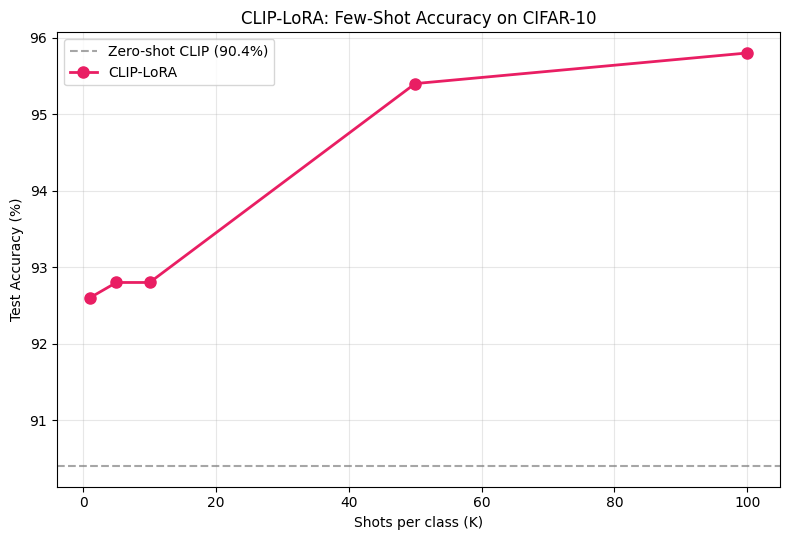

In [10]:
# ── Plot the few-shot learning curve ─────────────────────────────────────────
plt.figure(figsize=(8, 5.5))
plt.axhline(zeroshot_acc, color='gray', linestyle='--', alpha=0.7, label=f'Zero-shot CLIP ({zeroshot_acc:.1f}%)')
plt.plot(K_VALUES, [results['accuracy'][k] for k in K_VALUES], 'o-', linewidth=2, markersize=8, color='#E91E63', label='CLIP-LoRA')
plt.xlabel('Shots per class (K)')
plt.ylabel('Test Accuracy (%)')
plt.title('CLIP-LoRA: Few-Shot Accuracy on CIFAR-10')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('clip_lora_curve.png', dpi=150, bbox_inches='tight')
plt.show()

---

## Notes on fidelity and runtime

- LoRA rank defaults to 4 and is applied to **both** the visual and text transformers' QKV and output projections, matching the paper's scope.
- Because each forward pass now runs the *full* image and text encoders with gradients enabled (not cached embeddings like the linear-probe/Tip-Adapter notebooks), this is by far the slowest notebook in the set. Epoch count is reduced for K=50/100 to keep runtime reasonable — raise it back if you have spare GPU time.
- "Zero inference overhead" (the paper's claim) refers to merging the LoRA delta into the base weights permanently after training; here we keep them separate and merge at every forward pass, which is functionally identical but not literally merged into new weight tensors.